# Safe Q-Learning (SQRL) for Satellite Rendezvous

This notebook demonstrates training a Safe Q-Learning (SQRL) agent on the HCWSE2Env satellite rendezvous environment using the SafeGym package.

## Environment: HCWSE2Env
- **State**: [x, y, vx, vy, theta, omega] - position, velocity, attitude
- **Action**: [u_thrust, u_alpha] - thrust and rotational acceleration
- **Dynamics**: Hill-Clohessy-Wiltshire (HCW) equations for relative motion
- **Safety**: Position and velocity limits with safety constraints

## SQRL Algorithm
- **Safety Critic**: Learns safety constraints
- **Dual Critics**: Standard Q-learning with safety awareness
- **Safe Action Selection**: Actions filtered by safety constraints
- **Constraint Violation Tracking**: Monitors unsafe transitions


In [1]:
# Import required libraries
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
import json
from collections import deque

# Add project root to path
project_root = os.path.dirname(os.path.abspath('.'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import SafeGym components
from SafeGym.safegym.models.sqrl import SQRLAgent
from SafeGym.safegym.models.replaybuffer.replaybuffer import ReplayBuffer
from envs.arpod_HCW import HCWSE2Env

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Training configuration
config = {
    # Environment parameters
    'env_name': 'HCWSE2Env',
    'spawn_radius': (5.0, 25.0),  # (min, max) spawn distance in meters
    'max_episodes': 20000,
    'max_steps_per_episode': 1000,
    'render_frequency': 100,  # Render every N episodes
    
    # SQRL hyperparameters
    'gamma': 0.99,  # Discount factor for rewards
    'safe_gamma': 0.95,  # Discount factor for safety
    'tau': 0.005,  # Soft update rate for target networks
    'alpha': 0.2,  # Entropy regularization coefficient
    
    # SQRL safety hyperparameters
    'epsilon_safe': 0.1,  # Safety constraint threshold
    'nu': 0.1,  # Safety penalty coefficient
    
    # Learning rates
    'actor_lr': 3e-4,
    'critic_lr': 3e-4,
    'alpha_lr': 1e-4,
    'nu_lr': 1e-5,
    
    # Training parameters
    'buffer_size': 1000000,
    'batch_size': 256,
    'gradient_steps': 1,
    'update_frequency': 1,  # Update every N steps
    'target_update_frequency': 1,  # Update target networks every N updates
    
    # Network architecture
    'actor_net_arch': [256, 256,64],
    'critic_net_arch': [256, 256,64],
    'safety_critic_net_arch': [256, 256, 64],
    
    # Logging
    'log_frequency': 50,
    'save_frequency': 200,
    'eval_frequency': 100,
    'eval_episodes': 5,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")


Configuration:
  env_name: HCWSE2Env
  spawn_radius: (5.0, 25.0)
  max_episodes: 20000
  max_steps_per_episode: 1000
  render_frequency: 100
  gamma: 0.99
  safe_gamma: 0.95
  tau: 0.005
  alpha: 0.2
  epsilon_safe: 0.1
  nu: 0.1
  actor_lr: 0.0003
  critic_lr: 0.0003
  alpha_lr: 0.0001
  nu_lr: 1e-05
  buffer_size: 1000000
  batch_size: 256
  gradient_steps: 1
  update_frequency: 1
  target_update_frequency: 1
  actor_net_arch: [256, 256, 64]
  critic_net_arch: [256, 256, 64]
  safety_critic_net_arch: [256, 256, 64]
  log_frequency: 50
  save_frequency: 200
  eval_frequency: 100
  eval_episodes: 5


In [3]:
# Curriculum scheduler - mirror SAC schedule for spawn_radius phases
curriculum_config = {
    'enabled': True,
    'milestones': [
        {'episode': 1, 'spawn_radius': (2.5, 5.0)},
        {'episode': 250000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (2.5, 10.0)},
        {'episode': 500000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (2.5, 20.0)},
        {'episode': 1000000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (2.5, 40.0)},
        {'episode': 2000000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (2.5, 60.0)},
        {'episode': 3000000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (2.5, 80.0)},
        {'episode': 4000000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (2.5, 100.0)},
        {'episode': 5000000//(config.get('max_steps_per_episode',1000)), 'spawn_radius': (10.0, 100.0)},
    ]
}

class CurriculumScheduler:
    def __init__(self, cfg):
        self.enabled = cfg.get('enabled', False)
        self.milestones = sorted(cfg.get('milestones', []), key=lambda m: m['episode'])
        self.current = None

    def step(self, episode):
        if not self.enabled or not self.milestones:
            return {}
        selected = None
        for m in self.milestones:
            if episode >= m['episode']:
                selected = m
            else:
                break
        if selected is None:
            return {}
        if selected != self.current:
            self.current = selected.copy()
            return {k: v for k, v in selected.items() if k != 'episode'}
        return {}

def apply_curriculum_to_env(env, params):
    if not params:
        return False
    applied = False
    if 'spawn_radius' in params:
        try:
            if hasattr(env, 'envs'):
                for e in env.envs:
                    try:
                        setattr(e.unwrapped, 'spawn_radius', params['spawn_radius'])
                    except Exception:
                        try:
                            setattr(e, 'spawn_radius', params['spawn_radius'])
                        except Exception:
                            pass
            else:
                try:
                    setattr(env.unwrapped, 'spawn_radius', params['spawn_radius'])
                except Exception:
                    try:
                        setattr(env, 'spawn_radius', params['spawn_radius'])
                    except Exception:
                        pass
            applied = True
        except Exception:
            applied = False
    return applied

curriculum = CurriculumScheduler(curriculum_config)
print('Curriculum scheduler created for SQRL. Enabled:', curriculum.enabled)


Curriculum scheduler created for SQRL. Enabled: True


In [4]:
# Create output directories
run_specs = "SQRL_SafeGym"
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"runs/sqrl_hcw_{run_id}_{run_specs}"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/models", exist_ok=True)
os.makedirs(f"{output_dir}/logs", exist_ok=True)
os.makedirs(f"{output_dir}/plots", exist_ok=True)

# Save configuration
with open(f"{output_dir}/config.json", 'w') as f:
    json.dump(config, f, indent=2)

print(f"Output directory: {output_dir}")


Output directory: runs/sqrl_hcw_20250924_045709_SQRL_SafeGym


In [5]:
# Create environment
env = HCWSE2Env(
    render_mode=None,  # Set to "human" for visualization
    spawn_radius=config['spawn_radius'],
)

print(f"Environment created:")
print(f"  Observation space: {env.observation_space}")
print(f"  Action space: {env.action_space}")
print(f"  Max episode steps: {env.max_steps}")
print(f"  Spawn radius: {config['spawn_radius']}")


Environment created:
  Observation space: Box([-500.        -500.         -50.         -50.          -3.1415927
   -5.       ], [500.        500.         50.         50.          3.1415927   5.       ], (6,), float32)
  Action space: Box([ 0. -1.], 1.0, (2,), float32)
  Max episode steps: 3000
  Spawn radius: (5.0, 25.0)


In [6]:
# Create SQRL agent
agent = SQRLAgent(
    env=env,
    gamma=config['gamma'],
    safe_gamma=config['safe_gamma'],
    tau=config['tau'],
    alpha=config['alpha'],
    epsilon_safe=config['epsilon_safe'],
    actor_learning_rate=config['actor_lr'],
    critic_learning_rate=config['critic_lr'],
    buffer_size=config['buffer_size'],
    auto_entropy_tuning=True,
    nu=config['nu'],
    auto_nu_tuning=True,
    gradient_steps=config['gradient_steps'],
    policy_kwargs={
        'actor_net_arch': config['actor_net_arch'],
        'critic_net_arch': config['critic_net_arch'],
        'safety_critic_net_arch': config['safety_critic_net_arch'],
    },
    alpha_learning_rate=config['alpha_lr'],
    nu_learning_rate=config['nu_lr'],
)

print(f"SQRL Agent created:")
print(f"  Device: {agent.device}")
print(f"  Observation dim: {agent.obs_dim}")
print(f"  Action dim: {agent.action_dim}")
print(f"  Buffer size: {config['buffer_size']}")
print(f"  Safety threshold: {config['epsilon_safe']}")


SQRL Agent created:
  Device: cuda
  Observation dim: 6
  Action dim: 2
  Buffer size: 1000000
  Safety threshold: 0.1


In [7]:
# Training metrics tracking
training_metrics = {
    'episode_rewards': [],
    'episode_lengths': [],
    'safety_violations': [],
    'unsafe_actions': [],
    'actor_losses': [],
    'critic_losses': [],
    'safety_critic_losses': [],
    'alpha_values': [],
    'nu_values': [],
    'success_rate': [],
    'avg_reward': [],
    'avg_length': [],
    'avg_safety_violations': [],
    'safety_violation_rate': [],  # Percentage of episodes with violations
    'consecutive_safe_episodes': [],  # Track consecutive safe episodes
    'safety_violation_types': [],  # Track types of violations
    'max_safety_violations_per_episode': [],  # Track worst episodes
}

# Evaluation metrics
eval_metrics = {
    'eval_rewards': [],
    'eval_lengths': [],
    'eval_safety_violations': [],
    'eval_success_rate': [],
    'eval_safety_violation_rate': [],
}

# Safety violation tracking
safety_stats = {
    'total_violations': 0,
    'total_episodes': 0,
    'consecutive_safe': 0,
    'max_consecutive_safe': 0,
    'violation_types': {
        'attitude_fail': 0,
        'velocity_fail': 0,
        'velocity_theta_fail': 0,
        'omega_fail': 0,
        'out_of_bounds': 0,
    }
}

print("Enhanced training metrics initialized with safety tracking")


Enhanced training metrics initialized with safety tracking


In [8]:
# Safety function - get unsafe signal from environment info
def compute_unsafe(info):
    """Extract unsafe signal from environment info dictionary."""
    return int(info.get("is_unsafe", 0))

print("Safety function defined - using is_unsafe from environment info")


Safety function defined - using is_unsafe from environment info


In [9]:
# Training loop (dual-phase: switch based on curriculum milestone 4)
print("Starting SQRL training...")
print(f"Training for {config['max_episodes']} episodes")
print(f"Max steps per episode: {config['max_steps_per_episode']}")
print(f"Update frequency: {config['update_frequency']}")
print("-" * 50)

episode = 0
total_steps = 0
recent_rewards = deque(maxlen=100)
recent_lengths = deque(maxlen=100)
recent_safety_violations = deque(maxlen=100)

# Dual-phase control: start in pretraining, switch to finetuning when milestone 4 (index 3) reached
pretrain_mode = True
MILESTONE_INDEX_TRIGGER = 3
try:
    if 'curriculum' in globals() and len(curriculum.milestones) > MILESTONE_INDEX_TRIGGER:
        milestone_episode_threshold = int(curriculum.milestones[MILESTONE_INDEX_TRIGGER]['episode'])
    else:
        milestone_episode_threshold = float('inf')
except Exception:
    milestone_episode_threshold = float('inf')

print(f"[Phase] Pretraining will switch to finetuning at curriculum milestone episode >= {milestone_episode_threshold}")

while episode < config['max_episodes']:
    episode += 1
    
    # Apply curriculum for this episode
    try:
        new_params = curriculum.step(episode) if 'curriculum' in globals() else {}
        if new_params:
            applied = apply_curriculum_to_env(env, new_params)
            if applied:
                print(f"[Curriculum] Episode {episode}: applied {new_params}")
            else:
                print(f"[Curriculum] Episode {episode}: could not apply in-place, please restart or re-create env with {new_params}")
    except Exception as e:
        print("[Curriculum] Error while applying curriculum:", e)

    # Check and update SQRL phase based on milestone (episode count)
    current_pretrain_mode = episode < milestone_episode_threshold
    if current_pretrain_mode != pretrain_mode:
        pretrain_mode = current_pretrain_mode
        phase_name = "PRETRAINING" if pretrain_mode else "FINETUNING"
        print(f"[Phase] Switched to {phase_name} at episode={episode}")

    # Reset environment
    obs, info = env.reset()
    episode_reward = 0
    episode_length = 0
    episode_safety_violations = 0
    
    # Episode loop
    for step in range(config['max_steps_per_episode']):
        total_steps += 1
        episode_length += 1
        
        # Select action
        action = agent.select_action(obs)
        
        # Take step
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # Get unsafe signal from environment info
        unsafe = compute_unsafe(info)
        
        if unsafe:
            episode_safety_violations += 1
        
        # Store transition in replay buffer
        agent.replay_buffer.push(
            state=obs,
            action=action,
            reward=reward,
            next_state=next_obs,
            terminated=terminated,
            truncated=truncated,
            unsafe=unsafe
        )
        
        episode_reward += reward
        obs = next_obs
        
        # Update agent
        if (total_steps % config['update_frequency'] == 0 and 
            len(agent.replay_buffer) >= config['batch_size']):
            
            # Train with safety-aware sampling
            agent.train(batch_size=config['batch_size'], pretrain=current_pretrain_mode)
            
        
        # Check termination
        if terminated or truncated:
            break
    
    # Record episode metrics
    recent_rewards.append(episode_reward)
    recent_lengths.append(episode_length)
    recent_safety_violations.append(episode_safety_violations)
    
    training_metrics['episode_rewards'].append(episode_reward)
    training_metrics['episode_lengths'].append(episode_length)
    training_metrics['safety_violations'].append(episode_safety_violations)
    
    # Calculate success rate (episode completed without safety violations)
    success = episode_safety_violations == 0 and episode_length >= 10
    training_metrics['success_rate'].append(float(success))
    
    # Update safety statistics
    safety_stats['total_episodes'] += 1
    safety_stats['total_violations'] += episode_safety_violations
    
    if episode_safety_violations == 0:
        safety_stats['consecutive_safe'] += 1
        safety_stats['max_consecutive_safe'] = max(safety_stats['max_consecutive_safe'], safety_stats['consecutive_safe'])
    else:
        safety_stats['consecutive_safe'] = 0
        
    # Track violation types from the last info
    if 'done_reason' in info:
        violation_type = info['done_reason']
        if violation_type in safety_stats['violation_types']:
            safety_stats['violation_types'][violation_type] += 1
    
    # Record safety metrics
    training_metrics['consecutive_safe_episodes'].append(safety_stats['consecutive_safe'])
    training_metrics['max_safety_violations_per_episode'].append(max(training_metrics['safety_violations']) if training_metrics['safety_violations'] else 0)
    
    # Logging
    if episode % config['log_frequency'] == 0:
        avg_reward = np.mean(recent_rewards)
        avg_length = np.mean(recent_lengths)
        avg_safety_violations = np.mean(recent_safety_violations)
        success_rate = np.mean(training_metrics['success_rate'][-100:])
        
        # Calculate safety violation rate (percentage of episodes with violations)
        recent_episodes = min(100, len(training_metrics['safety_violations']))
        recent_violation_episodes = sum(1 for v in training_metrics['safety_violations'][-recent_episodes:] if v > 0)
        safety_violation_rate = (recent_violation_episodes / recent_episodes) * 100
        
        training_metrics['avg_reward'].append(avg_reward)
        training_metrics['avg_length'].append(avg_length)
        training_metrics['avg_safety_violations'].append(avg_safety_violations)
        training_metrics['safety_violation_rate'].append(safety_violation_rate)
        
        # Safety alert system
        safety_alert = ""
        if episode_safety_violations > 0:
            safety_alert = f" ⚠️  SAFETY VIOLATION! ({episode_safety_violations} violations)"
        elif safety_violation_rate > 20:
            safety_alert = f" ⚠️  HIGH VIOLATION RATE: {safety_violation_rate:.1f}%"
        elif safety_stats['consecutive_safe'] > 50:
            safety_alert = f" ✅ {safety_stats['consecutive_safe']} consecutive safe episodes!"
        
        print(f"Episode {episode:4d} | "
              f"Reward: {episode_reward:8.2f} | "
              f"Avg Reward: {avg_reward:8.2f} | "
              f"Length: {episode_length:4d} | "
              f"Safety Violations: {episode_safety_violations:2d} | "
              f"Success Rate: {success_rate:.3f} | "
              f"Violation Rate: {safety_violation_rate:5.1f}%{safety_alert}")
        
        # Additional safety statistics every 200 episodes
        if episode % 200 == 0:
            print(f"\n📊 SAFETY STATISTICS (Episodes 1-{episode}):")
            print(f"   Total Violations: {safety_stats['total_violations']}")
            print(f"   Violation Rate: {(safety_stats['total_violations']/safety_stats['total_episodes']*100):.2f}%")
            print(f"   Max Consecutive Safe: {safety_stats['max_consecutive_safe']}")
            print(f"   Current Consecutive Safe: {safety_stats['consecutive_safe']}")
            print(f"   Violation Types:")
            for vtype, count in safety_stats['violation_types'].items():
                if count > 0:
                    print(f"     {vtype}: {count}")
            print()
    
    # Save model
    if episode % config['save_frequency'] == 0:
        torch.save({
            'episode': episode,
            'agent_state_dict': {
                'actor': agent.actor.state_dict(),
                'critic1': agent.critic1.state_dict(),
                'critic2': agent.critic2.state_dict(),
                'safety_critic': agent.safety_critic.state_dict(),
            },
            'optimizer_state_dict': {
                'actor': agent.actor_optimizer.state_dict(),
                'critic1': agent.critic1_optimizer.state_dict(),
                'critic2': agent.critic2_optimizer.state_dict(),
                'safety_critic': agent.safety_critic_optimizer.state_dict(),
            },
            'training_metrics': training_metrics,
        }, f"{output_dir}/models/agent_episode_{episode}.pth")
        
        # Save training metrics
        np.save(f"{output_dir}/logs/training_metrics.npy", training_metrics)
    
    # Evaluation
    if episode % config['eval_frequency'] == 0:
        eval_rewards = []
        eval_lengths = []
        eval_safety_violations = []
        eval_successes = []
        
        for eval_ep in range(config['eval_episodes']):
            eval_obs, eval_info = env.reset()
            eval_reward = 0
            eval_length = 0
            eval_safety_violations_ep = 0
            
            for _ in range(config['max_steps_per_episode']):
                eval_action = agent.select_action(eval_obs)
                eval_next_obs, eval_r, eval_term, eval_trunc, eval_info = env.step(eval_action)
                
                eval_unsafe = compute_unsafe(eval_info)
                if eval_unsafe:
                    eval_safety_violations_ep += 1
                
                eval_reward += eval_r
                eval_length += 1
                eval_obs = eval_next_obs
                
                if eval_term or eval_trunc:
                    break
            
            eval_rewards.append(eval_reward)
            eval_lengths.append(eval_length)
            eval_safety_violations.append(eval_safety_violations_ep)
            eval_successes.append(eval_safety_violations_ep == 0)
        
        eval_metrics['eval_rewards'].append(np.mean(eval_rewards))
        eval_metrics['eval_lengths'].append(np.mean(eval_lengths))
        eval_metrics['eval_safety_violations'].append(np.mean(eval_safety_violations))
        eval_metrics['eval_success_rate'].append(np.mean(eval_successes))
        
        # Calculate evaluation safety violation rate
        eval_violation_rate = (sum(1 for v in eval_safety_violations if v > 0) / len(eval_safety_violations)) * 100
        eval_metrics['eval_safety_violation_rate'].append(eval_violation_rate)
        
        # Safety status for evaluation
        eval_safety_status = ""
        if np.mean(eval_safety_violations) == 0:
            eval_safety_status = " ✅ ALL SAFE"
        elif eval_violation_rate > 50:
            eval_safety_status = " ⚠️  HIGH VIOLATIONS"
        else:
            eval_safety_status = " ⚠️  SOME VIOLATIONS"
        
        print(f"Evaluation | Avg Reward: {np.mean(eval_rewards):8.2f} | "
              f"Avg Length: {np.mean(eval_lengths):6.1f} | "
              f"Safety Violations: {np.mean(eval_safety_violations):6.1f} | "
              f"Success Rate: {np.mean(eval_successes):.3f} | "
              f"Violation Rate: {eval_violation_rate:5.1f}%{eval_safety_status}")

print("\nTraining completed!")
print(f"Total episodes: {episode}")
print(f"Total steps: {total_steps}")
print(f"Final average reward: {np.mean(recent_rewards):.2f}")
print(f"Final success rate: {np.mean(training_metrics['success_rate'][-100:]):.3f}")


Starting SQRL training...
Training for 20000 episodes
Max steps per episode: 1000
Update frequency: 1
--------------------------------------------------
[Phase] Pretraining will switch to finetuning at curriculum milestone episode >= 1000
[Curriculum] Episode 1: applied {'spawn_radius': (2.5, 5.0)}
Episode   50 | Reward:    91.80 | Avg Reward:  -137.93 | Length: 1000 | Safety Violations:  0 | Success Rate: 0.800 | Violation Rate:  20.0%
Episode  100 | Reward:    57.25 | Avg Reward:   -61.47 | Length:   63 | Safety Violations:  0 | Success Rate: 0.760 | Violation Rate:  24.0% ⚠️  HIGH VIOLATION RATE: 24.0%
Evaluation | Avg Reward:    22.19 | Avg Length:  509.4 | Safety Violations:    0.4 | Success Rate: 0.600 | Violation Rate:  40.0% ⚠️  SOME VIOLATIONS
Episode  150 | Reward:   -13.79 | Avg Reward:    65.06 | Length: 1000 | Safety Violations:  0 | Success Rate: 0.780 | Violation Rate:  22.0% ⚠️  HIGH VIOLATION RATE: 22.0%
Episode  200 | Reward:   263.18 | Avg Reward:   124.60 | Length: 

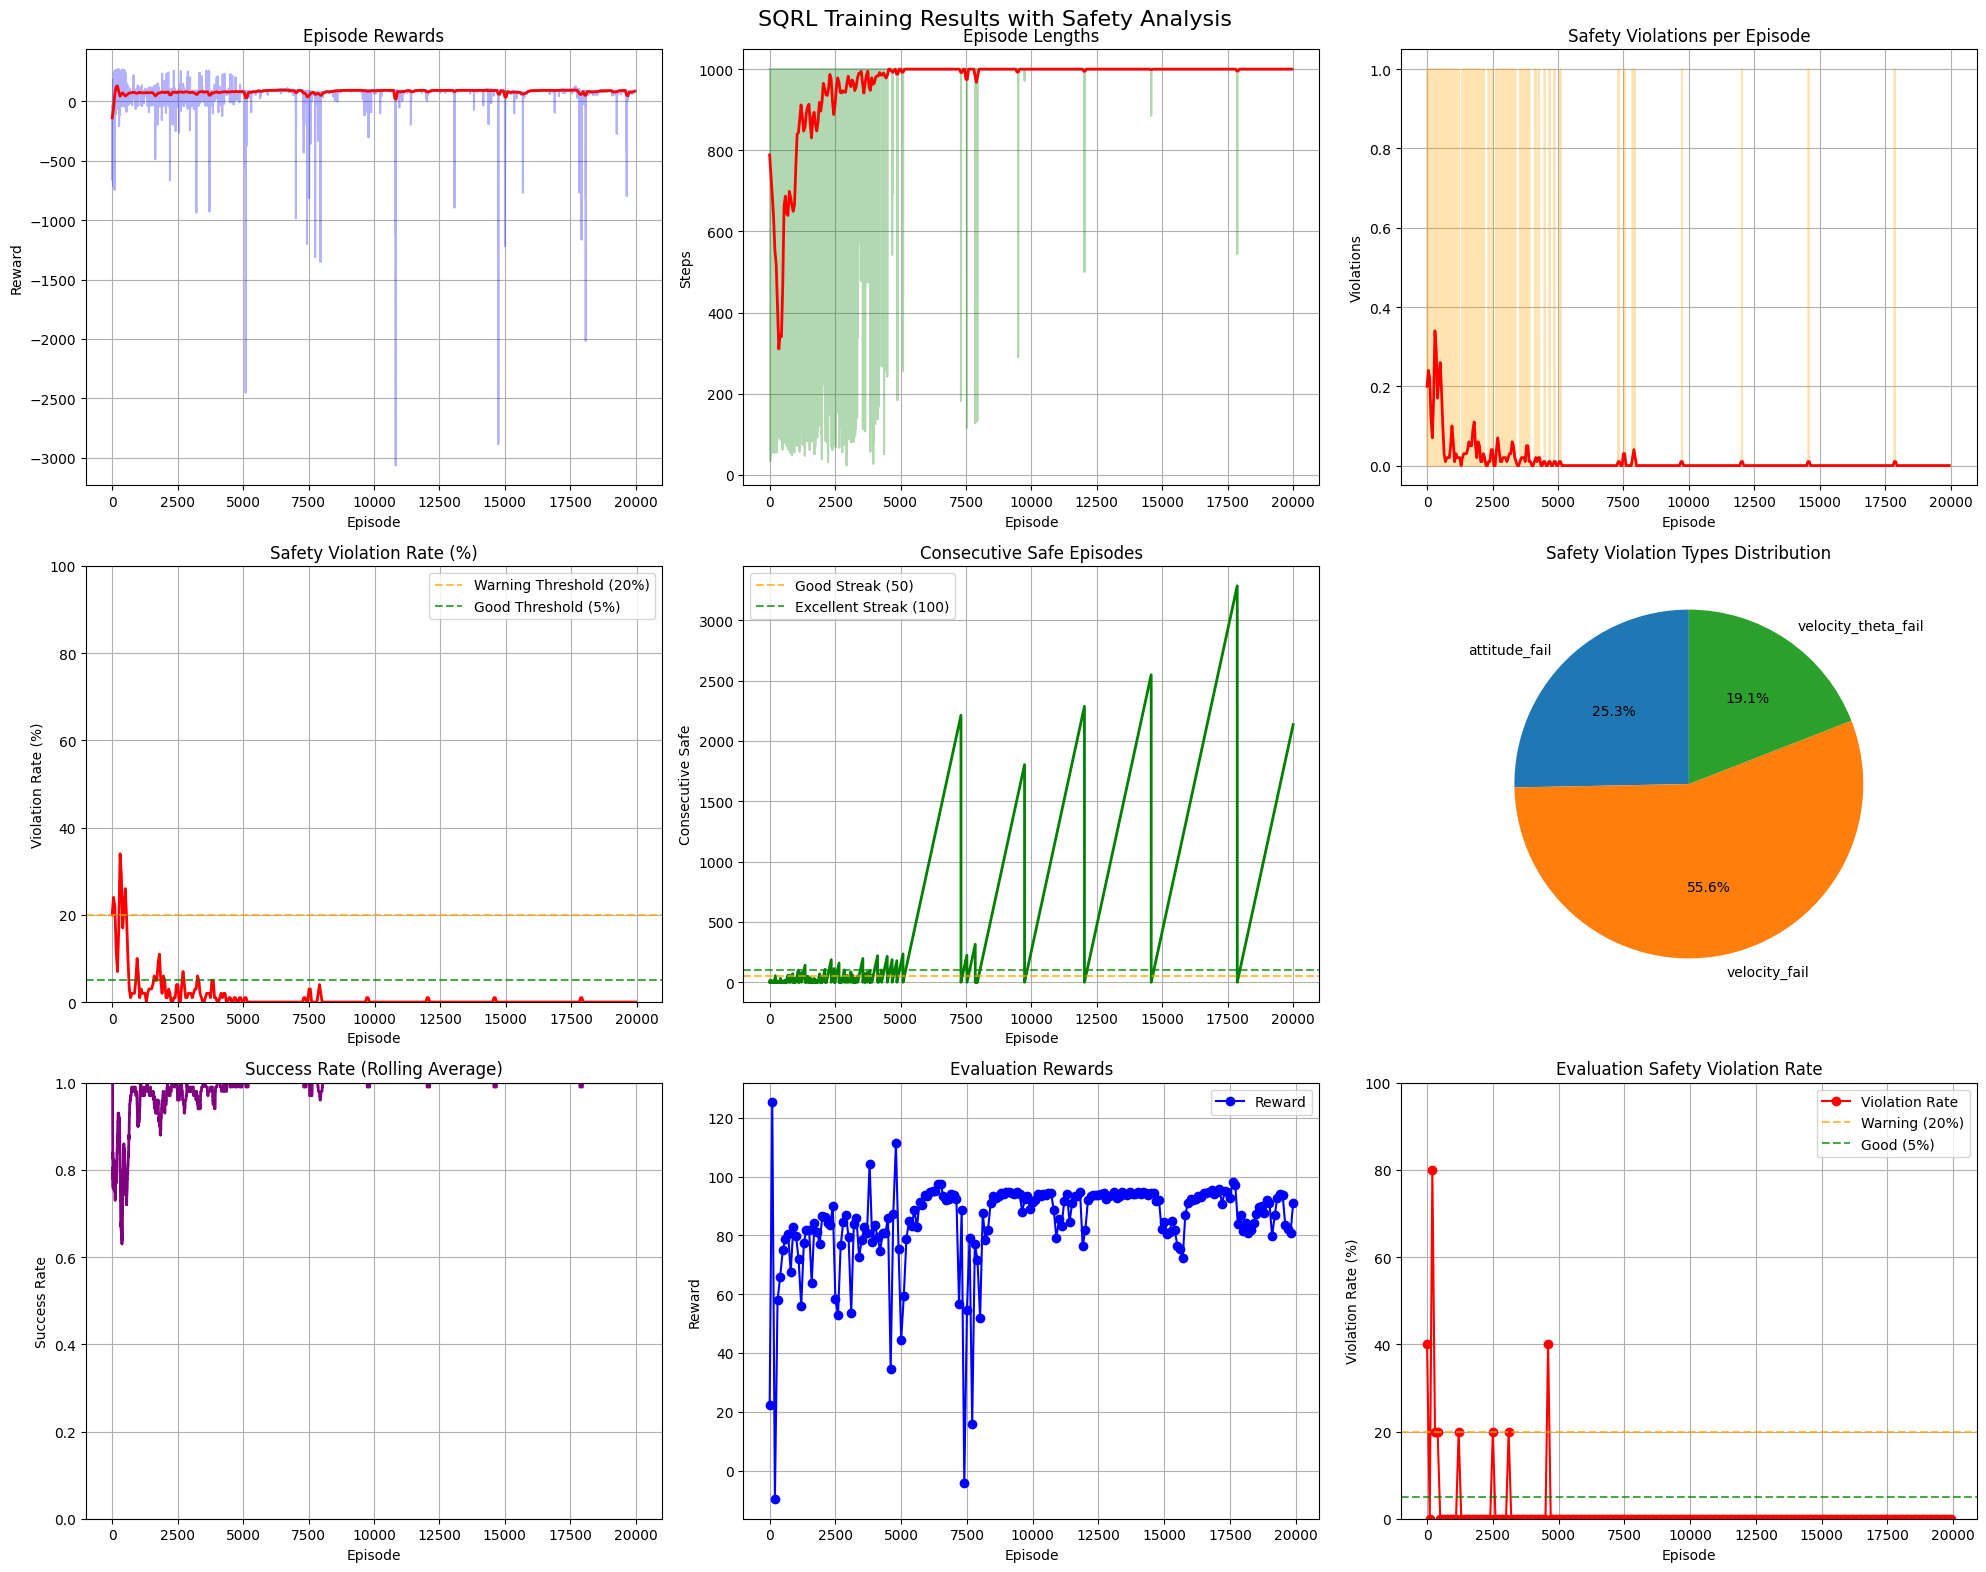

Plots saved to runs/sqrl_hcw_20250924_045709_SQRL_SafeGym/plots/


In [10]:
# Plot training results
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('SQRL Training Results with Safety Analysis', fontsize=16)

# Episode rewards
axes[0, 0].plot(training_metrics['episode_rewards'], alpha=0.3, color='blue')
if training_metrics['avg_reward']:
    axes[0, 0].plot(np.arange(0, len(training_metrics['avg_reward'])) * config['log_frequency'], 
                    training_metrics['avg_reward'], color='red', linewidth=2)
axes[0, 0].set_title('Episode Rewards')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].grid(True)

# Episode lengths
axes[0, 1].plot(training_metrics['episode_lengths'], alpha=0.3, color='green')
if training_metrics['avg_length']:
    axes[0, 1].plot(np.arange(0, len(training_metrics['avg_length'])) * config['log_frequency'], 
                    training_metrics['avg_length'], color='red', linewidth=2)
axes[0, 1].set_title('Episode Lengths')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].grid(True)

# Safety violations per episode
axes[0, 2].plot(training_metrics['safety_violations'], alpha=0.3, color='orange')
if training_metrics['avg_safety_violations']:
    axes[0, 2].plot(np.arange(0, len(training_metrics['avg_safety_violations'])) * config['log_frequency'], 
                    training_metrics['avg_safety_violations'], color='red', linewidth=2)
axes[0, 2].set_title('Safety Violations per Episode')
axes[0, 2].set_xlabel('Episode')
axes[0, 2].set_ylabel('Violations')
axes[0, 2].grid(True)

# Safety violation rate (percentage of episodes with violations)
if training_metrics['safety_violation_rate']:
    axes[1, 0].plot(np.arange(0, len(training_metrics['safety_violation_rate'])) * config['log_frequency'], 
                    training_metrics['safety_violation_rate'], color='red', linewidth=2)
    axes[1, 0].axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='Warning Threshold (20%)')
    axes[1, 0].axhline(y=5, color='green', linestyle='--', alpha=0.7, label='Good Threshold (5%)')
axes[1, 0].set_title('Safety Violation Rate (%)')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Violation Rate (%)')
axes[1, 0].grid(True)
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 100)

# Consecutive safe episodes
if training_metrics['consecutive_safe_episodes']:
    axes[1, 1].plot(training_metrics['consecutive_safe_episodes'], color='green', linewidth=2)
    axes[1, 1].axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='Good Streak (50)')
    axes[1, 1].axhline(y=100, color='green', linestyle='--', alpha=0.7, label='Excellent Streak (100)')
axes[1, 1].set_title('Consecutive Safe Episodes')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Consecutive Safe')
axes[1, 1].grid(True)
axes[1, 1].legend()

# Safety violation types (pie chart)
if safety_stats['violation_types']:
    violation_counts = [count for count in safety_stats['violation_types'].values() if count > 0]
    violation_labels = [label for label, count in safety_stats['violation_types'].items() if count > 0]
    if violation_counts:
        axes[1, 2].pie(violation_counts, labels=violation_labels, autopct='%1.1f%%', startangle=90)
        axes[1, 2].set_title('Safety Violation Types Distribution')
    else:
        axes[1, 2].text(0.5, 0.5, 'No Violations!', ha='center', va='center', transform=axes[1, 2].transAxes, fontsize=14)
        axes[1, 2].set_title('Safety Violation Types Distribution')

# Success rate
if training_metrics['success_rate']:
    # Calculate rolling average
    window = 100
    success_rate_rolling = []
    for i in range(len(training_metrics['success_rate'])):
        start_idx = max(0, i - window + 1)
        success_rate_rolling.append(np.mean(training_metrics['success_rate'][start_idx:i+1]))
    
    axes[2, 0].plot(success_rate_rolling, color='purple', linewidth=2)
    axes[2, 0].set_title('Success Rate (Rolling Average)')
    axes[2, 0].set_xlabel('Episode')
    axes[2, 0].set_ylabel('Success Rate')
    axes[2, 0].grid(True)
    axes[2, 0].set_ylim(0, 1)

# Evaluation metrics
if eval_metrics['eval_rewards']:
    eval_episodes = np.arange(0, len(eval_metrics['eval_rewards'])) * config['eval_frequency']
    axes[2, 1].plot(eval_episodes, eval_metrics['eval_rewards'], 'o-', color='blue', label='Reward')
    axes[2, 1].set_title('Evaluation Rewards')
    axes[2, 1].set_xlabel('Episode')
    axes[2, 1].set_ylabel('Reward')
    axes[2, 1].grid(True)
    axes[2, 1].legend()

# Evaluation safety metrics
if eval_metrics['eval_safety_violation_rate']:
    axes[2, 2].plot(eval_episodes, eval_metrics['eval_safety_violation_rate'], 'o-', color='red', label='Violation Rate')
    axes[2, 2].axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='Warning (20%)')
    axes[2, 2].axhline(y=5, color='green', linestyle='--', alpha=0.7, label='Good (5%)')
    axes[2, 2].set_title('Evaluation Safety Violation Rate')
    axes[2, 2].set_xlabel('Episode')
    axes[2, 2].set_ylabel('Violation Rate (%)')
    axes[2, 2].grid(True)
    axes[2, 2].legend()
    axes[2, 2].set_ylim(0, 100)
else:
    axes[2, 2].text(0.5, 0.5, 'No Evaluation Data', ha='center', va='center', transform=axes[2, 2].transAxes)
    axes[2, 2].set_title('Evaluation Safety Violation Rate')

plt.tight_layout()
plt.savefig(f"{output_dir}/plots/training_results.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plots saved to {output_dir}/plots/")


In [11]:
# Safety Analysis Report
print("=" * 60)
print("🔍 DETAILED SAFETY ANALYSIS REPORT")
print("=" * 60)

# Overall safety statistics
total_episodes = len(training_metrics['episode_rewards'])
total_violations = sum(training_metrics['safety_violations'])
overall_violation_rate = (total_violations / total_episodes) * 100 if total_episodes > 0 else 0

print(f"\n📊 OVERALL SAFETY STATISTICS:")
print(f"   Total Episodes: {total_episodes}")
print(f"   Total Safety Violations: {total_violations}")
print(f"   Overall Violation Rate: {overall_violation_rate:.2f}%")
print(f"   Episodes with Violations: {sum(1 for v in training_metrics['safety_violations'] if v > 0)}")
print(f"   Episodes without Violations: {sum(1 for v in training_metrics['safety_violations'] if v == 0)}")

# Safety trends
if len(training_metrics['safety_violations']) > 100:
    first_half = training_metrics['safety_violations'][:len(training_metrics['safety_violations'])//2]
    second_half = training_metrics['safety_violations'][len(training_metrics['safety_violations'])//2:]
    
    first_half_rate = (sum(1 for v in first_half if v > 0) / len(first_half)) * 100
    second_half_rate = (sum(1 for v in second_half if v > 0) / len(second_half)) * 100
    
    print(f"\n📈 SAFETY IMPROVEMENT TRENDS:")
    print(f"   First Half Violation Rate: {first_half_rate:.2f}%")
    print(f"   Second Half Violation Rate: {second_half_rate:.2f}%")
    improvement = first_half_rate - second_half_rate
    if improvement > 0:
        print(f"   ✅ Safety Improved by {improvement:.2f} percentage points")
    elif improvement < 0:
        print(f"   ⚠️  Safety Degraded by {abs(improvement):.2f} percentage points")
    else:
        print(f"   ➡️  Safety remained constant")

# Consecutive safe episodes analysis
max_consecutive = max(training_metrics['consecutive_safe_episodes']) if training_metrics['consecutive_safe_episodes'] else 0
current_consecutive = training_metrics['consecutive_safe_episodes'][-1] if training_metrics['consecutive_safe_episodes'] else 0

print(f"\n🏆 CONSECUTIVE SAFE EPISODES:")
print(f"   Maximum Consecutive Safe: {max_consecutive}")
print(f"   Current Consecutive Safe: {current_consecutive}")

# Violation type analysis
print(f"\n🔍 VIOLATION TYPE BREAKDOWN:")
for vtype, count in safety_stats['violation_types'].items():
    if count > 0:
        percentage = (count / total_violations) * 100 if total_violations > 0 else 0
        print(f"   {vtype}: {count} ({percentage:.1f}%)")

# Safety recommendations
print(f"\n💡 SAFETY RECOMMENDATIONS:")
if overall_violation_rate > 20:
    print("   ⚠️  HIGH VIOLATION RATE - Consider:")
    print("      • Reducing learning rate")
    print("      • Increasing safety penalty weights")
    print("      • Adding more safety constraints")
elif overall_violation_rate > 5:
    print("   ⚠️  MODERATE VIOLATION RATE - Consider:")
    print("      • Fine-tuning safety parameters")
    print("      • Increasing training episodes")
elif overall_violation_rate > 0:
    print("   ✅ LOW VIOLATION RATE - Good progress!")
    print("      • Continue current approach")
    print("      • Monitor for any degradation")
else:
    print("   🎉 PERFECT SAFETY RECORD!")
    print("      • Excellent training results")
    print("      • Consider testing on more challenging scenarios")

# Recent performance
if len(training_metrics['safety_violations']) >= 50:
    recent_episodes = training_metrics['safety_violations'][-50:]
    recent_violation_rate = (sum(1 for v in recent_episodes if v > 0) / len(recent_episodes)) * 100
    print(f"\n📊 RECENT PERFORMANCE (Last 50 Episodes):")
    print(f"   Recent Violation Rate: {recent_violation_rate:.2f}%")
    if recent_violation_rate < overall_violation_rate:
        print("   ✅ Recent performance is better than overall average")
    elif recent_violation_rate > overall_violation_rate:
        print("   ⚠️  Recent performance is worse than overall average")

print("\n" + "=" * 60)


🔍 DETAILED SAFETY ANALYSIS REPORT

📊 OVERALL SAFETY STATISTICS:
   Total Episodes: 20000
   Total Safety Violations: 241
   Overall Violation Rate: 1.21%
   Episodes with Violations: 241
   Episodes without Violations: 19759

📈 SAFETY IMPROVEMENT TRENDS:
   First Half Violation Rate: 2.38%
   Second Half Violation Rate: 0.03%
   ✅ Safety Improved by 2.35 percentage points

🏆 CONSECUTIVE SAFE EPISODES:
   Maximum Consecutive Safe: 3286
   Current Consecutive Safe: 2135

🔍 VIOLATION TYPE BREAKDOWN:
   attitude_fail: 61 (25.3%)
   velocity_fail: 134 (55.6%)
   velocity_theta_fail: 46 (19.1%)

💡 SAFETY RECOMMENDATIONS:
   ✅ LOW VIOLATION RATE - Good progress!
      • Continue current approach
      • Monitor for any degradation

📊 RECENT PERFORMANCE (Last 50 Episodes):
   Recent Violation Rate: 0.00%
   ✅ Recent performance is better than overall average



In [12]:
# Test trained agent
print("Testing trained agent...")

# Create test environment with rendering
test_env = HCWSE2Env(
    render_mode="human",  # Enable rendering for visualization
    spawn_radius=config['spawn_radius'],
    pos_limit=100.0,
    v_limit=10.0,
    theta_limit=0.5,
    omega_limit=0.5,
)

# Test episodes
test_episodes = 3
test_results = []

for test_ep in range(test_episodes):
    print(f"\nTest Episode {test_ep + 1}/{test_episodes}")
    
    obs, info = test_env.reset()
    test_reward = 0
    test_length = 0
    test_safety_violations = 0
    
    for step in range(config['max_steps_per_episode']):
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, info = test_env.step(action)
        
        test_unsafe = compute_unsafe(info)
        if test_unsafe:
            test_safety_violations += 1
        
        test_reward += reward
        test_length += 1
        obs = next_obs
        
        if terminated or truncated:
            break
    
    test_results.append({
        'episode': test_ep + 1,
        'reward': test_reward,
        'length': test_length,
        'safety_violations': test_safety_violations,
        'success': test_safety_violations == 0
    })
    
    print(f"  Reward: {test_reward:.2f}")
    print(f"  Length: {test_length}")
    print(f"  Safety Violations: {test_safety_violations}")
    print(f"  Success: {test_safety_violations == 0}")

test_env.close()

# Summary
avg_test_reward = np.mean([r['reward'] for r in test_results])
avg_test_length = np.mean([r['length'] for r in test_results])
avg_test_safety_violations = np.mean([r['safety_violations'] for r in test_results])
test_success_rate = np.mean([r['success'] for r in test_results])

print(f"\nTest Results Summary:")
print(f"  Average Reward: {avg_test_reward:.2f}")
print(f"  Average Length: {avg_test_length:.1f}")
print(f"  Average Safety Violations: {avg_test_safety_violations:.1f}")
print(f"  Success Rate: {test_success_rate:.3f}")


Testing trained agent...

Test Episode 1/3
  Reward: -50.00
  Length: 1
  Safety Violations: 0
  Success: True

Test Episode 2/3
  Reward: -50.03
  Length: 1
  Safety Violations: 0
  Success: True

Test Episode 3/3
  Reward: -50.04
  Length: 1
  Safety Violations: 0
  Success: True

Test Results Summary:
  Average Reward: -50.03
  Average Length: 1.0
  Average Safety Violations: 0.0
  Success Rate: 1.000


In [13]:
# Save final results
final_results = {
    'config': config,
    'training_metrics': training_metrics,
    'eval_metrics': eval_metrics,
    'test_results': test_results,
    'final_stats': {
        'total_episodes': episode,
        'total_steps': total_steps,
        'final_avg_reward': np.mean(recent_rewards) if recent_rewards else 0,
        'final_success_rate': np.mean(training_metrics['success_rate'][-100:]) if training_metrics['success_rate'] else 0,
        'test_avg_reward': avg_test_reward,
        'test_success_rate': test_success_rate,
    }
}

# Save results
with open(f"{output_dir}/final_results.json", 'w') as f:
    # Convert numpy arrays to lists for JSON serialization
    def convert_numpy(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {key: convert_numpy(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_numpy(item) for item in obj]
        else:
            return obj
    
    json.dump(convert_numpy(final_results), f, indent=2)

print(f"\nResults saved to {output_dir}/")
print(f"Final model saved to {output_dir}/models/")
print(f"Training plots saved to {output_dir}/plots/")
print(f"Logs saved to {output_dir}/logs/")

print("\nSQRL Training Complete!")
print("=" * 50)



Results saved to runs/sqrl_hcw_20250924_045709_SQRL_SafeGym/
Final model saved to runs/sqrl_hcw_20250924_045709_SQRL_SafeGym/models/
Training plots saved to runs/sqrl_hcw_20250924_045709_SQRL_SafeGym/plots/
Logs saved to runs/sqrl_hcw_20250924_045709_SQRL_SafeGym/logs/

SQRL Training Complete!


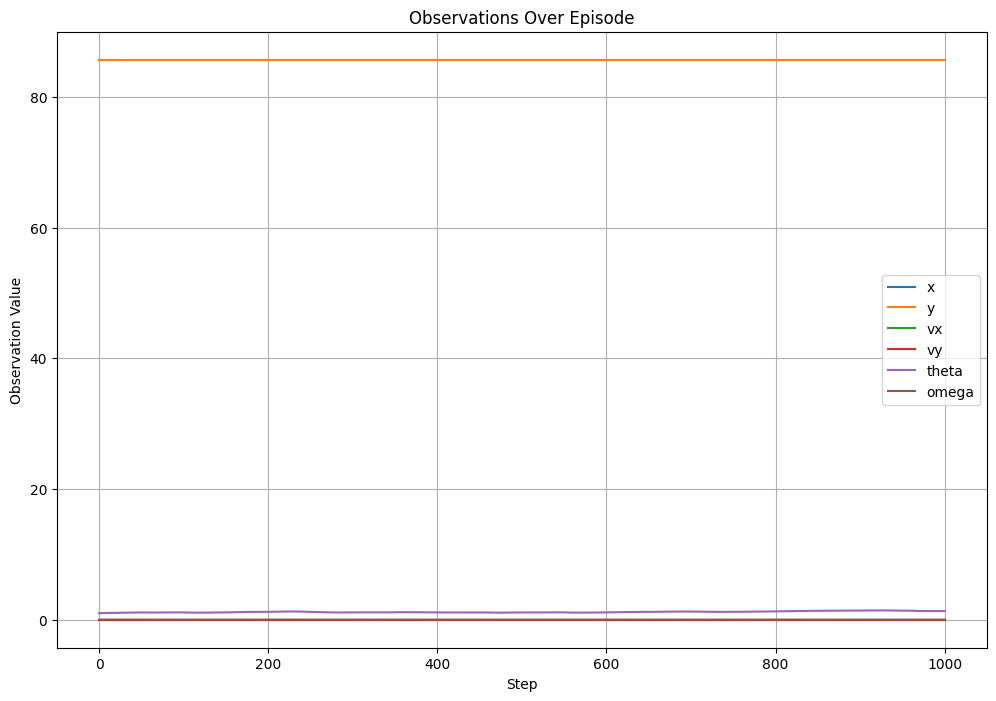

In [16]:
# Generate a single episode and plot the observations

obs_list = []
obs, info = env.reset()
obs_list.append(obs.copy())

for step in range(config['max_steps_per_episode']):
    action = agent.select_action(obs)
    next_obs, reward, terminated, truncated, info = env.step(action)
    obs_list.append(next_obs.copy())
    obs = next_obs
    if terminated or truncated:
        break

obs_array = np.array(obs_list)

plt.figure(figsize=(12, 8))
labels = ['x', 'y', 'vx', 'vy', 'theta', 'omega']
for i in range(obs_array.shape[1]):
    plt.plot(obs_array[:, i], label=labels[i])
plt.title('Observations Over Episode')
plt.xlabel('Step')
plt.ylabel('Observation Value')
plt.legend()
plt.grid(True)
plt.show()